In [1]:
import numpy as np
import torch
import torch.nn as nn

import sys
sys.path.insert(0, '../include')

from phase_shifts import compute_phase_shifts, fit_potential, convert_to_wavenumber
from plot import plot_wavefunction, plot_wavefunctions
from sampling import TrainConfig
from scipy_eigensolver import solve_1channel
from training import train_Rayleigh, train_Rayleigh_PDE
from validation import validate, print_metrics

## Fit parameters from ³S₁ phase shifts

Use the Stoks *et al.* PRC 48 (1993) 792 data (low-energy subset, $T_\mathrm{lab} \leq 100$ MeV)
to fit the two square-well parameters $V_0$ and $R_0$ by minimising

$$\chi^2 = \sum_i \bigl[\delta_0(k_i;\, V_0, R_0) - \tilde\delta(k_i)\bigr]^2, \qquad V(r) = -V_0\,\theta(R_0 - r)$$

Simple central potentials cannot reproduce the high-energy phase shifts (missing repulsive core),
so we restrict the fit to the low-energy region where the potential shape is most constrained.

In [4]:
# Stoks et al., PRC 48 (1993) 792, Table V  (low-energy subset, Tlab <= 100 MeV)
Tlab   = np.array([1, 5, 10, 25, 50], dtype=float)
np_3S1 = np.array([147.747, 118.178, 102.611, 80.63, 62.77])
k_exp, _ = convert_to_wavenumber(Tlab, input_type='T_lab')

# Square-well template:  V(r) = -V0  if r <= R0,  else 0
def V_sq(r, V0, R0):
    return np.where(r <= R0, -V0, 0.0)

params_opt, res = fit_potential(
    V_sq,
    params_init=[60.0, 1.5],
    k_data=k_exp, delta_data=np_3S1,
    bounds=[(10, 300), (0.5, 4.0)],
    n_bound_states=1,
)
V0, R0 = params_opt

print(f'Fitted parameters:')
print(f'  V0 = {V0:.3f} MeV    R0 = {R0:.4f} fm')
print(f'  chi2 = {res.fun:.4g}   converged: {res.success}')
print()

delta_fit = compute_phase_shifts(lambda r: V_sq(r, *params_opt), k_exp, n_bound_states=1)
print(f'{"Tlab":>6}  {"data":>8}  {"fit":>8}  {"resid":>7}')
for Tl, de, df in zip(Tlab, np_3S1, delta_fit):
    print(f'{Tl:6.0f}  {de:8.3f}  {df:8.3f}  {df-de:+7.3f}')

r_min = 1e-4
r_max = 30.0
r = np.linspace(r_min, r_max, 1000)

Fitted parameters:
  V0 = 59.152 MeV    R0 = 1.5000 fm
  chi2 = 191.6   converged: False

  Tlab      data       fit    resid
     1   147.747   149.028   +1.281
     5   118.178   121.536   +3.358
    10   102.611   107.538   +4.927
    25    80.630    88.208   +7.578
    50    62.770    72.617   +9.847


Solve with scipy

Ground state energy E = -2.081675 MeV


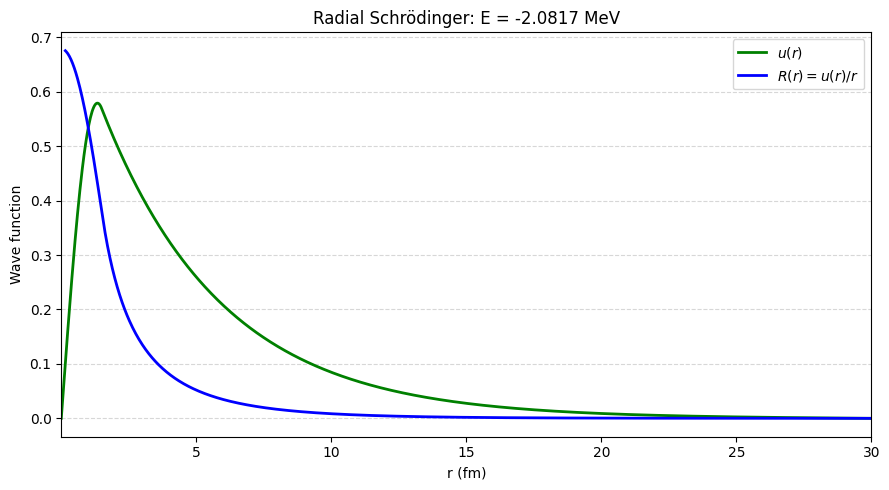

In [5]:
def square_well(r):
    return np.where(r <= R0, -V0, 0.0)

E_scipy, u_scipy, R_scipy = solve_1channel(square_well, r)
plot_wavefunction(r, u_scipy, R_scipy, E_scipy)

Define a neural network $N_\theta(r)$ that approximates the radial wave function via an ansatz
$$
u_\theta(r) = r e^{-\alpha r} N_{\theta}(r) \text{ with } \alpha = 0.25 \text{ fm}^{-1}.
$$
The network input is rescaled from $[0,r_{\max}]$ to $[-1,1]$.

In [6]:
class RadialNet(nn.Module):
    def __init__(self, hidden_dim=64, num_layers=3, alpha=0.25, energy_init=-3.0):
        # Define layers
        super().__init__()
        layers = [nn.Linear(1, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

        self.register_buffer('alpha', torch.tensor(float(alpha)))
        self.energy = nn.Parameter(torch.tensor([energy_init], dtype=torch.float32))

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.dtype = torch.float32

        self.r_min = r_min
        self.r_max = r_max
        self.R = R0

    # Forward pass
    def forward(self, r):
        # r is expected to be of shape (N, 1)
        x = 2.0 * r / self.r_max - 1.0 # mapping to [-1,1]
        return r * torch.exp(-self.alpha * r) * self.net(x)

    # Potential
    def potential(self, r):
        return torch.where(r <= R0, -V0, torch.tensor(0.0))

Train with Rayleigh energy only

In [7]:
cfg = TrainConfig()
cfg.n_rayleigh = 5000

model = RadialNet()

history = train_Rayleigh(model, cfg, stop=1e-3)

{'step': 1, 'loss': 4.294702529907227, 'rayleigh': 0.030974319204688072, 'norm_loss': 0.426371306180954, 'boundary_loss': 1.5136957927097683e-06, 'E': 0.030974319204688072}
{'step': 500, 'loss': -2.7207577228546143, 'rayleigh': -2.8933539390563965, 'norm_loss': 0.017256762832403183, 'boundary_loss': 2.8524443678179523e-06, 'E': -2.8933539390563965}
{'step': 1000, 'loss': -1.7593525648117065, 'rayleigh': -1.7743260860443115, 'norm_loss': 0.0014965587761253119, 'boundary_loss': 8.017069603738491e-07, 'E': -1.7743260860443115}
{'step': 1500, 'loss': -0.8972705006599426, 'rayleigh': -0.9412240982055664, 'norm_loss': 0.004394287709146738, 'boundary_loss': 1.0719952570070745e-06, 'E': -0.9412240982055664}
{'step': 2000, 'loss': -3.146817445755005, 'rayleigh': -3.1498184204101562, 'norm_loss': 0.0002999630232807249, 'boundary_loss': 1.4901844735959457e-07, 'E': -3.1498184204101562}
{'step': 2500, 'loss': -0.6031546592712402, 'rayleigh': -0.6205838322639465, 'norm_loss': 0.0017418245552107692,

In [8]:
metrics, u_nn, R_nn = validate(r, u_scipy, R_scipy, E_scipy, model)
print_metrics(metrics)

  rayleigh_energy: -1.8109879
  norm_loss: 0.00087654608
  pde_loss: 1.8667947
  u_rmax: 0.001027629
  l2: 0.0079213127
  learned_energy: -2.0692306
  energy_error: 0.012444095


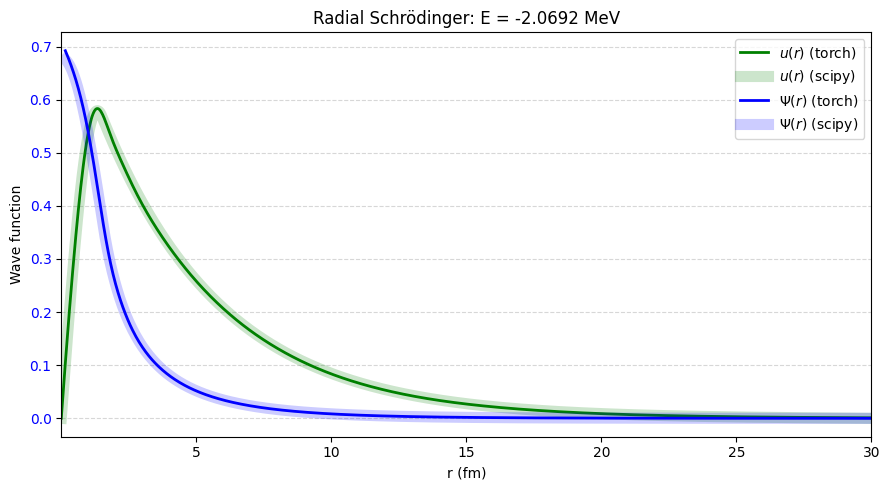

In [9]:
plot_wavefunctions(r, u_scipy, R_scipy, u_nn, R_nn, metrics['learned_energy'])

Train with both Rayleigh and PDE terms

In [10]:
cfg2 = TrainConfig()
cfg2.n_origin = 2000
cfg2.n_pde = 8000
cfg2.n_rayleigh = 8000
cfg2.grad_balance_pde_scale = 3.0
#cfg2.grad_balance_match_scale = 2.0

model2 = RadialNet()

history2 = train_Rayleigh_PDE(model2, cfg2, stop=1e-4)

{'step': 1, 'loss': 6.734229564666748, 'rayleigh': 0.20439928770065308, 'pde_loss': 1.003644347190857, 'match_loss': 10.26817512512207, 'norm_loss': 0.6529772281646729, 'boundary_loss': 5.824876097904053e-06, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 500, 'loss': -0.9847217798233032, 'rayleigh': -1.0531277656555176, 'pde_loss': 75.08969116210938, 'match_loss': 3.790311574935913, 'norm_loss': 0.006839164067059755, 'boundary_loss': 1.4339224208015366e-06, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 1000, 'loss': -5.189306735992432, 'rayleigh': -5.20628547668457, 'pde_loss': 9.549400329589844, 'match_loss': 4.8676958084106445, 'norm_loss': 0.0016967657720670104, 'boundary_loss': 1.1198412721569184e-06, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 1500, 'loss': -1.6234349012374878, 'rayleigh': -1.6371878385543823, 'pde_loss': 7.713934898376465, 'match_loss': 1.8572570085525513, 'norm_loss': 0.001374196377582848, 'boundary_loss': 1.0954111075

In [11]:
metrics2, u_nn2, R_nn2 = validate(r, u_scipy, R_scipy, E_scipy, model2)
print_metrics(metrics2)

  rayleigh_energy: -1.8124553
  norm_loss: 0.002940218
  pde_loss: 0.24819125
  u_rmax: 0.0024417161
  l2: 0.09540195
  learned_energy: -2.0389371
  energy_error: 0.042737559


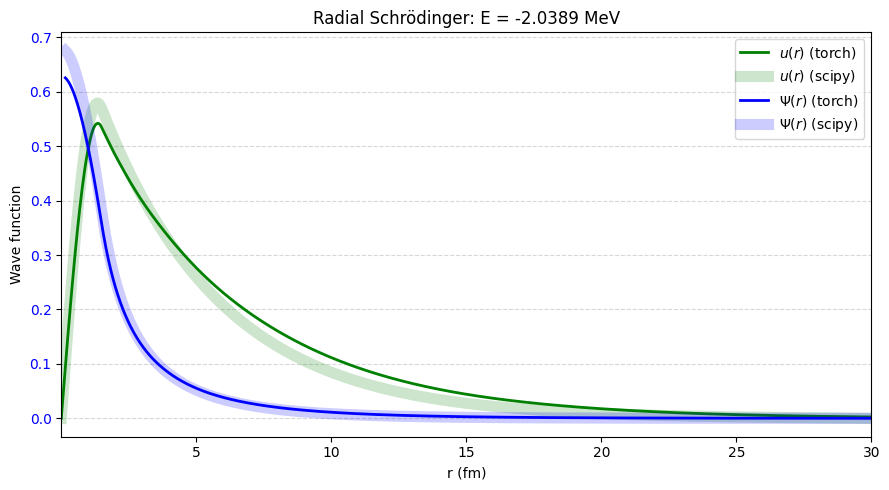

In [12]:
plot_wavefunctions(r, u_scipy, R_scipy, u_nn2, R_nn2, metrics2['learned_energy'])